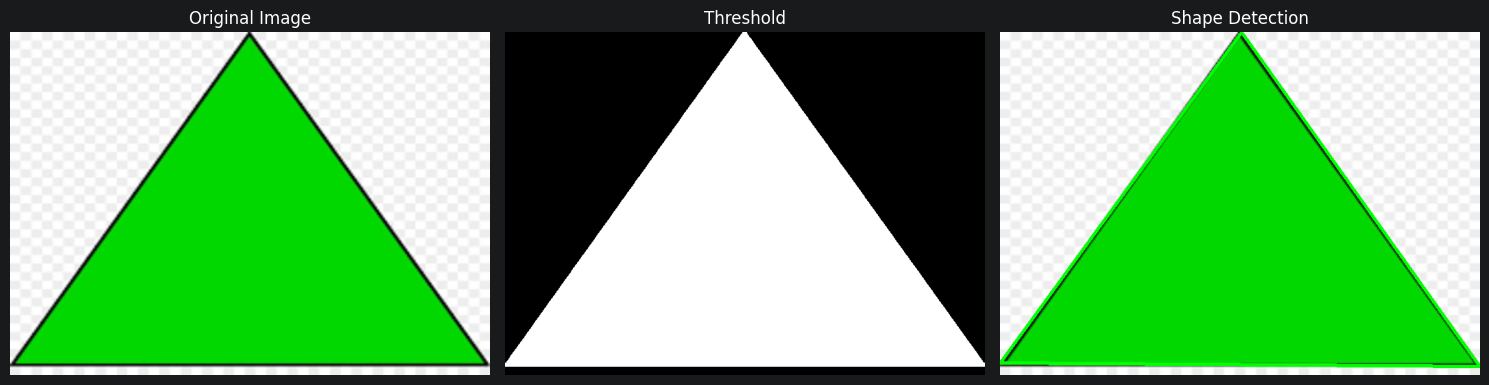

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# LAB 12 - NHẬN DẠNG 3 VẬT THỂ
# ==================================================

# Đọc ảnh
image = cv2.imread("img_data/tam_giac.jpg")

# Kiểm tra ảnh
if image is None:
    print("Không đọc được ảnh!")
    exit()

# Resize ảnh
image = cv2.resize(image, (700, 500))

# Tạo bản sao để vẽ kết quả
output = image.copy()

# ==================================================
# TIỀN XỬ LÝ ẢNH
# ==================================================

# Chuyển sang ảnh xám
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Làm mờ để giảm nhiễu
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Threshold tạo ảnh nhị phân
_, thresh = cv2.threshold(
    blur,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# ==================================================
# KHỬ NHIỄU
# ==================================================

kernel = np.ones((3, 3), np.uint8)

thresh = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel
)

# ==================================================
# TÌM CONTOUR
# ==================================================

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# ==================================================
# NHẬN DẠNG HÌNH DẠNG
# ==================================================

for cnt in contours:

    # Tính diện tích contour
    area = cv2.contourArea(cnt)

    # Bỏ qua contour quá nhỏ
    if area < 500:
        continue

    # Tính chu vi
    perimeter = cv2.arcLength(cnt, True)

    # Xấp xỉ contour thành đa giác
    approx = cv2.approxPolyDP(
        cnt,
        0.02 * perimeter,
        True
    )

    # Đếm số đỉnh
    vertices = len(approx)

    # Bounding box
    x, y, w, h = cv2.boundingRect(approx)

    shape = "Unknown"

    # ==================================================
    # PHÂN LOẠI HÌNH
    # ==================================================

    # Tam giác
    if vertices == 3:
        shape = "Triangle"

    # Hình vuông / chữ nhật
    elif vertices == 4:

        aspect_ratio = w / float(h)

        # Hình vuông
        if 0.95 <= aspect_ratio <= 1.05:
            shape = "Square"

        # Hình chữ nhật
        else:
            shape = "Rectangle"

    # Hình tròn
    else:
        shape = "Circle"

    # ==================================================
    # VẼ KẾT QUẢ
    # ==================================================

    # Vẽ contour
    cv2.drawContours(
        output,
        [approx],
        -1,
        (0, 255, 0),
        3
    )

    # Hiển thị tên hình
    cv2.putText(
        output,
        shape,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        2
    )

# ==================================================
# CHUYỂN BGR -> RGB ĐỂ HIỂN THỊ VỚI MATPLOTLIB
# ==================================================

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# ==================================================
# HIỂN THỊ KẾT QUẢ
# ==================================================

plt.figure(figsize=(15, 5))

# Ảnh gốc
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# Ảnh threshold
plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")

# Ảnh kết quả
plt.subplot(1, 3, 3)
plt.imshow(output_rgb)
plt.title("Shape Detection")
plt.axis("off")

plt.tight_layout()
plt.show()
